In [1]:
# Now try to calculate the l=2 mode of the remote quadrupole field
from sympy import *
from sympy.tensor.array.expressions import ArrayTensorProduct
import numpy as np
import my_remote_spectra as rs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import importlib
importlib.reload(rs)
# import remote_spectra as RS
import ipdb
import pdb
import scipy.optimize as optimize
import kszpsz_config as conf
import matplotlib.pyplot as plt

In [2]:
import param
import config as config
import kszpsz_config as kszpsz_config

Omega_b = config.Omega_b
Omega_c = config.Omega_c
w = config.w
wa = config.wa
Omega_K = config.Omega_K
h = config.h
As= config.As
ns = config.ns
tau = config.tau

A = 1
B = 0
r_H = param.r_H #Mpc
z_c = 0
Z_e = 1
a_e = 1/(1+Z_e)
a_dec = kszpsz_config.adec

x_c = rs.chifromz(z_c) #Mpc
r_e = rs.chifromz(Z_e)
r_edec = rs.chifromz(config.zdec) - rs.chifromz(Z_e)
r_dec = rs.chifromz(config.zdec)
D_psi_dec = rs.Dpsi_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_dec)
D_v_dec = rs.Dv_inter(Omega_b, Omega_c, w, wa, Omega_K, h)(a_dec)

In [3]:
import bubble_collision_sym as bc_sym
importlib.reload(bc_sym)
evaluate = True
BC_sym = bc_sym.BubbleCollision_RF_sym(A, B, z_c, Z_e, Omega_b, Omega_c, w, wa, Omega_K, h)
# BC_sym.check_remote_region()
BC_sym.Cos_theta_c()
BC_sym.Delta_cos_theta_c_n(Symbol('n'))
BC_sym.remote_region_bound
BC_sym.local_region_bound
BC_sym.RDF_eff_SW(evaluate=evaluate)

BC_sym.RDF_eff_decDopp(evaluate=evaluate)
BC_sym.RDF_eff_localDopp(evaluate=evaluate)

BC_sym.RQF_eff_decDopp(evaluate=evaluate)
BC_sym.RQF_eff_SW(evaluate=evaluate)
BC_sym.RQF_eff_ISW(evaluate=evaluate)

<module 'bubble_collision_sym' from '/home/hongbo/tools/ReCCO/code/bubble_collision_sym.py'>

[(chi_c - chi_e*cos(theta_e))/Delta_chi_dec, -1, 1]

[1 - ((chi_c - chi_e*cos(theta_e))/Delta_chi_dec)**n, 1 - (-1)**n, 1 - 1**n]

[[0.0, 180.0], [], []]

[[0.0, 89.54773869346734], [90.45226130653266, 180.0]]

...

[3*D_v_dec*(A*(1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi_dec**3)/(3*r_H) + B*Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**4/Delta_chi_dec**4)/(2*r_H**2) + 2*B*(1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi_dec**3)*(-chi_c + chi_e*cos(theta_e))/(3*r_H**2))*cos(theta_e)/2, 3*D_v_dec*(2*A/(3*r_H) + 4*B*(-chi_c + chi_e*cos(theta_e))/(3*r_H**2))*cos(theta_e)/2, 0]

[-D_v_e*(A + 2*B*(-chi_c + chi_e*cos(theta_e))/r_H)*cos(theta_e)/r_H, 0]

[5*sqrt(6)*D_v_dec*(A*(1/4 + (chi_c - chi_e*cos(theta_e))**2/(2*Delta_chi_dec**2) - 3*(chi_c - chi_e*cos(theta_e))**4/(4*Delta_chi_dec**4))/r_H + 2*B*(3*Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**5/Delta_chi_dec**5)/5 - Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi_dec**3)/3 + (1 - (chi_c - chi_e*cos(theta_e))**4/Delta_chi_dec**4)*(-3*chi_c/4 + 3*chi_e*cos(theta_e)/4) - (1 - (chi_c - chi_e*cos(theta_e))**2/Delta_chi_dec**2)*(-chi_c/2 + chi_e*cos(theta_e)/2))/r_H**2)*sin(theta_e)**2/16, sqrt(6)*B*D_v_dec*Delta_chi_dec*sin(theta_e)**2/(3*r_H**2), 0]

[sqrt(6)*(10*D_psi_dec - 15/2)*(A*(3*Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**4/Delta_chi_dec**4)/4 - Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**2/Delta_chi_dec**2)/2 + (1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi_dec**3)*(-chi_c + chi_e*cos(theta_e)) - (1 - (chi_c - chi_e*cos(theta_e))/Delta_chi_dec)*(-chi_c + chi_e*cos(theta_e)))/r_H + B*(3*Delta_chi_dec**2*(1 - (chi_c - chi_e*cos(theta_e))**5/Delta_chi_dec**5)/5 + 3*Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**4/Delta_chi_dec**4)*(-chi_c + chi_e*cos(theta_e))/2 - Delta_chi_dec*(1 - (chi_c - chi_e*cos(theta_e))**2/Delta_chi_dec**2)*(-chi_c + chi_e*cos(theta_e)) + (1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi_dec**3)*(-Delta_chi_dec**2/3 + (-chi_c + chi_e*cos(theta_e))**2) - (1 - (chi_c - chi_e*cos(theta_e))/Delta_chi_dec)*(-chi_c + chi_e*cos(theta_e))**2)/r_H**2)*sin(theta_e)**2/16, sqrt(6)*B*Delta_chi_dec**2*(10*D_psi_dec - 15/2)*sin(theta_e)**2/(30*r_H**2), 0]

[Integral(5*sqrt(6)*(A*(3*Delta_chi*(1 - (chi_c - chi_e*cos(theta_e))**4/Delta_chi**4)/4 - Delta_chi*(1 - (chi_c - chi_e*cos(theta_e))**2/Delta_chi**2)/2 + (1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi**3)*(-chi_c + chi_e*cos(theta_e)) - (1 - (chi_c - chi_e*cos(theta_e))/Delta_chi)*(-chi_c + chi_e*cos(theta_e)))/r_H + B*(3*Delta_chi**2*(1 - (chi_c - chi_e*cos(theta_e))**5/Delta_chi**5)/5 + 3*Delta_chi*(1 - (chi_c - chi_e*cos(theta_e))**4/Delta_chi**4)*(-chi_c + chi_e*cos(theta_e))/2 - Delta_chi*(1 - (chi_c - chi_e*cos(theta_e))**2/Delta_chi**2)*(-chi_c + chi_e*cos(theta_e)) + (1 - (chi_c - chi_e*cos(theta_e))**3/Delta_chi**3)*(-Delta_chi**2/3 + (-chi_c + chi_e*cos(theta_e))**2) - (1 - (chi_c - chi_e*cos(theta_e))/Delta_chi)*(-chi_c + chi_e*cos(theta_e))**2)/r_H**2)*sin(theta_e)**2*Derivative(D_psi, a)/16, a), Integral(sqrt(6)*B*Delta_chi**2*sin(theta_e)**2*Derivative(D_psi, a)/(6*r_H**2), a), Integral(0, a)]

In [4]:
BC_sym.q_l2m0_at_bound_sym('SW')

[15*sqrt(5)*sqrt(pi)*(2*D_psi_dec - 3/2)*(-A*Delta_chi_dec*sin(theta_e)**4*cos(theta_e)/(4*r_H) - A*Delta_chi_dec*sin(theta_e)**2*cos(theta_e)**3/(3*r_H) - 2*A*Delta_chi_dec*cos(theta_e)**5/(15*r_H) + A*chi_c**2*sin(theta_e)**4*cos(theta_e)/(2*Delta_chi_dec*r_H) + 2*A*chi_c**2*sin(theta_e)**2*cos(theta_e)**3/(3*Delta_chi_dec*r_H) + 4*A*chi_c**2*cos(theta_e)**5/(15*Delta_chi_dec*r_H) + A*chi_c*chi_e*sin(theta_e)**6/(6*Delta_chi_dec*r_H) + A*chi_e**2*sin(theta_e)**4*cos(theta_e)**3/(6*Delta_chi_dec*r_H) + 2*A*chi_e**2*sin(theta_e)**2*cos(theta_e)**5/(15*Delta_chi_dec*r_H) + 4*A*chi_e**2*cos(theta_e)**7/(105*Delta_chi_dec*r_H) - A*chi_c**4*sin(theta_e)**4*cos(theta_e)/(4*Delta_chi_dec**3*r_H) - A*chi_c**4*sin(theta_e)**2*cos(theta_e)**3/(3*Delta_chi_dec**3*r_H) - 2*A*chi_c**4*cos(theta_e)**5/(15*Delta_chi_dec**3*r_H) - A*chi_c**3*chi_e*sin(theta_e)**6/(6*Delta_chi_dec**3*r_H) - A*chi_c**2*chi_e**2*sin(theta_e)**4*cos(theta_e)**3/(2*Delta_chi_dec**3*r_H) - 2*A*chi_c**2*chi_e**2*sin(theta_e

In [5]:
BC_sym.q_l2m0_at_bound_sym('ISW')

no symbolic form RQF-ISW multipoles


In [6]:
BC_sym.v_l1m0_at_bound_sym('ISW')

no symbolic form RDF-ISW multipoles


In [7]:
BC_sym.v_l1m0_at_bound_sym('decDopp')

[3*sqrt(3)*sqrt(pi)*D_v_dec*(-A*cos(theta_e)**3/(9*r_H) + A*chi_c**3*cos(theta_e)**3/(9*Delta_chi_dec**3*r_H) - A*chi_c**2*chi_e*cos(theta_e)**4/(4*Delta_chi_dec**3*r_H) + A*chi_c*chi_e**2*cos(theta_e)**5/(5*Delta_chi_dec**3*r_H) - A*chi_e**3*cos(theta_e)**6/(18*Delta_chi_dec**3*r_H) - B*Delta_chi_dec*cos(theta_e)**3/(6*r_H**2) + 2*B*chi_c*cos(theta_e)**3/(9*r_H**2) - B*chi_e*cos(theta_e)**4/(6*r_H**2) - B*chi_c**4*cos(theta_e)**3/(18*Delta_chi_dec**3*r_H**2) + B*chi_c**3*chi_e*cos(theta_e)**4/(6*Delta_chi_dec**3*r_H**2) - B*chi_c**2*chi_e**2*cos(theta_e)**5/(5*Delta_chi_dec**3*r_H**2) + B*chi_c*chi_e**3*cos(theta_e)**6/(9*Delta_chi_dec**3*r_H**2) - B*chi_e**4*cos(theta_e)**7/(42*Delta_chi_dec**3*r_H**2))/2, 3*sqrt(3)*sqrt(pi)*D_v_dec*(-2*A*cos(theta_e)**3/(9*r_H) + 4*B*chi_c*cos(theta_e)**3/(9*r_H**2) - B*chi_e*cos(theta_e)**4/(3*r_H**2))/2, 0]

In [8]:
BC_sym.v_l1m0('SW')
BC_sym.v_l1m0('localDopp')
BC_sym.v_l1m0('decDopp')
BC_sym.v_l1m0('ISW')

0.9016537658854972

-0.7357574242554452

0.027366043120255652

/home/hongbo/tools/ReCCO/code/bubble_collision.py:85: RuntimeWarning: divide by zero encountered in divide
  cos_theta_c = (self.chi_c -self.chi_e*cos_theta_e)/chi_edec


-0.19555283084185013

In [9]:
BC_sym.q_l2m0('SW')
BC_sym.q_l2m0('decDopp')
BC_sym.q_l2m0('ISW')

0.42368757160641846

0.013623921902784332

/home/hongbo/tools/ReCCO/code/bubble_collision.py:139: RuntimeWarning: divide by zero encountered in divide
  cos_theta_c = (self.chi_c -self.chi_e*cos_theta_e)/chi_edec


-0.08516578149475311

In [10]:
%load_ext autoreload
%autoreload 2

In [13]:
PkDeltaDelta = rs.get_PkDeltaDelta(2)

In [15]:
rs.root_tau2z(6, Omega_b, h, tau)

-0.01928555980448591

In [20]:
zguess = 6
sol = optimize.root(rs.root_tau2z, zguess, args=(Omega_b, h, tau))

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'root_chi2a'.Shape should be (100,) but it is (100, 100).

In [21]:
rs.get_CLEE()

Calculating Cl_EE...


TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'root_chi2a'.Shape should be (100,) but it is (100, 100).

In [59]:
from my_remote_spectra import *
from scipy.interpolate import interp1d, interp2d
k = k_sampling()
L = L_sampling()
a = 0.5
z = 4
chi = 11000
transfer_E = np.zeros((len(k), len(L)), dtype=np.complex64)
Tk = rs.T(k, Omega_b, Omega_c, w, wa, Omega_K, h)

In [60]:
transfer_E = np.zeros((len(k), len(L)), dtype=np.complex64)
Tk = T(k, Omega_b, Omega_c, w, wa, Omega_K, h)
Chi_grid = np.linspace(0.1, chi, 100)
Z_grid = zfromchi(Chi_grid)
a_grid = az(Z_grid)
sigma_ne = sigma_nez(Z_grid, Omega_b, h)
etau = np.exp(-tau_grid(Chi_grid, Z_grid, Omega_b, h))
Integrand = np.zeros((len(k), len(L), len(Chi_grid)), dtype=np.complex64)

In [61]:
for i in np.arange(len(Chi_grid)):
    Integrand[:, :, i] = (-np.sqrt(6.0)/10.0)*Transfer_psz_redshift(k, L, Z_grid[i], Omega_b, Omega_c, w, wa, Omega_K, h)*\
    a_grid[i]*sigma_ne[i]*etau[i]

In [62]:
transfer_E = integrate.simps(Integrand, Chi_grid, axis=-1)

/tmp/ipykernel_1081040/55807161.py:1: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  transfer_E = integrate.simps(Integrand, Chi_grid, axis=-1)


In [63]:
LE = np.arange(conf.E_estim_signal_lmax)
T_list = [transfer_E]

In [64]:
np.arange(conf.E_estim_signal_lmax)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [65]:
transfer_E.shape

(1000, 100)

In [66]:
CL_EE = CL_bins(T_list, T_list, k, LE, conf.As, conf.ns)

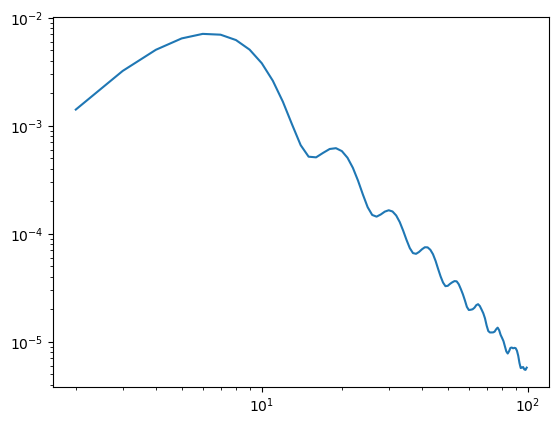

In [67]:
factor = L*(L+1)/(2*np.pi)
plt.plot(L[2:], 9e10*(factor*CL_EE)[0,2:])
plt.xscale('log')
plt.yscale('log')

In [12]:
import spectra as sp
from math import gamma
from sympy.physics.wigner import wigner_3j

In [13]:
wigner_3j(2, 1000, 1000, 0, 0, 0)

-10*sqrt(80200099949970)/8011997997

In [14]:
sp.wigner_symbol(2, 1000, 1000)

-0.011177550037651448

In [15]:
rs.tau_z(z, Omega_b, h)

0.023008677939813333

In [16]:
zguess = 6
sol = optimize.root(rs.root_tau2z, zguess, args=(Omega_b, h, tau))

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'root_chi2a'.Shape should be (100,) but it is (100, 100).

In [12]:
rs.tau_z(0.5, Omega_b, h)

0.0013848024061709726

In [13]:
rs.root_tau2z(100, Omega_b, h, tau)

2.379366269336304

In [14]:
rs.root_chi2a(a, 3000, Omega_b, Omega_c, w, wa, Omega_K, h)

383.07573908498034

In [15]:
chi_grid = np.linspace(0, chi, 100)
chi_grid.shape

z_grid = rs.zfromchi(chi_grid)
z_grid.shape

(100,)

(100,)

In [16]:
import kszpsz_config as conf
ag = np.logspace(np.log10(conf.adec), 0, conf.transfer_integrand_sampling)

In [36]:
rs.Transfer_E(k, L, Omega_b, Omega_c, w, wa, Omega_K, h, tau)

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'root_chi2a'.Shape should be (100,) but it is (100, 100).

In [17]:
ag.shape

(1000,)

In [18]:
afromchi = interp1d(rs.Chia(Omega_b, Omega_c, w, wa, Omega_K, h), ag, kind="cubic", bounds_error=False, fill_value='extrapolate')
sol = optimize.root(rs.root_chi2a, afromchi(chi), args=(chi, Omega_b, Omega_c, w, wa, Omega_K, h))
sol.x

array([0.53994519])

In [19]:
rs.z_re(Omega_b, h, tau)

TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'root_chi2a'.Shape should be (100,) but it is (100, 100).

# Then we calculate some power spectra!

In [49]:
rs.get_CLEE()

Calculating Cl_EE...


TypeError: fsolve: there is a mismatch between the input and output shape of the 'func' argument 'root_chi2a'.Shape should be (100,) but it is (100, 100).

In [10]:
# To calculate Fisher matrix of A, B, Z_c
# Numeric or analytic?
# Have to test firstly with some toy parameters
As = [0, 1, 2, 3, 4]
Bs = [0, 1, 2, 3, 4]
z_c = [0, 1, 2, 3, 4]

In [11]:
BC_sym.clvv_l1('SW')
BC_sym.clqq_l2('SW')

0.8129795135354989

0.17951115833374395